In [1]:
# Cell 1 — Imports
# Import numpy for numerical operations
import numpy as np

# Import trimesh for mesh processing
import trimesh

# Import matplotlib for plotting slice contours
import matplotlib.pyplot as plt

In [2]:
# Set the mesh file path
mesh_path = "first.glb"

# Set the real body height in centimeters
real_height_cm = 175.0

# Set the vertical axis: 0 = X, 1 = Y, 2 = Z
# This mesh is Y-up, so use 1
vertical_axis = 1

# Set the number of smoothing iterations
smooth_iterations = 3

# Set whether to use convex hull for chest, waist, and hip
use_convex_hull_for_body = True

# Set whether to show plots
show_plots = True

# Print the settings
print("Mesh path:", mesh_path)
print("Real height (cm):", real_height_cm)
print("Vertical axis:", vertical_axis)
print("Smoothing iterations:", smooth_iterations)
print("Use convex hull for body slices:", use_convex_hull_for_body)
print("Show plots:", show_plots)

Mesh path: first.glb
Real height (cm): 175.0
Vertical axis: 1
Smoothing iterations: 3
Use convex hull for body slices: True
Show plots: True


In [3]:
# Cell 3 — Load mesh
# Print status
print("Loading mesh...")

# Load the file
loaded = trimesh.load(mesh_path)

# Check if the loaded object is a scene
if isinstance(loaded, trimesh.Scene):
    # Print status
    print("Loaded object is a Scene. Merging geometries...")

    # Create list for geometries
    meshes = []

    # Loop through all geometries in the scene
    for name, geom in loaded.geometry.items():
        # Append geometry to the list
        meshes.append(geom)

    # Merge all geometries into one mesh
    mesh = trimesh.util.concatenate(meshes)
else:
    # Use the loaded object directly
    mesh = loaded

# Print confirmation
print("Mesh loaded successfully.")
print("Vertices:", len(mesh.vertices))
print("Faces:", len(mesh.faces))

Loading mesh...
Loaded object is a Scene. Merging geometries...
Mesh loaded successfully.
Vertices: 18439
Faces: 36874


In [4]:
# Cell 4 — Clean mesh
# Safety check
if "mesh" not in globals():
    raise RuntimeError("Mesh not loaded. Please run Cell 3 first.")

# Print status
print("Cleaning mesh (version-safe)...")

# Try to remove NaN and infinite values
try:
    mesh.remove_infinite_values()
    print("Removed infinite values.")
except:
    print("remove_infinite_values not available. Skipping.")

# Try to merge duplicate vertices
try:
    mesh.merge_vertices()
    print("Merged duplicate vertices.")
except:
    print("merge_vertices not available. Skipping.")

# Print status
print("Removing degenerate faces manually...")

# Get triangle coordinates
triangles = mesh.triangles

# Compute triangle cross products
cross_prod = np.cross(
    triangles[:, 1] - triangles[:, 0],
    triangles[:, 2] - triangles[:, 0]
)

# Compute triangle areas
areas = np.linalg.norm(cross_prod, axis=1) * 0.5

# Create valid face mask
valid_faces = areas > 1e-12

# Update faces using valid mask
mesh.update_faces(valid_faces)

# Print status
print("Degenerate faces removed.")

# Print status
print("Removing unreferenced vertices...")

# Find used vertex indices
used_vertices = np.unique(mesh.faces.flatten())

# Create mask for used vertices
vertex_mask = np.isin(np.arange(len(mesh.vertices)), used_vertices)

# Update vertices
mesh.update_vertices(mask=vertex_mask)

# Print status
print("Unreferenced vertices removed.")

# Try to rezero mesh
try:
    mesh.rezero()
    print("Mesh rezero applied.")
except:
    print("rezero not available.")

# Try to fix normals
try:
    mesh.fix_normals()
    print("Normals fixed.")
except:
    print("fix_normals not available.")

# Try to fill holes
try:
    mesh.fill_holes()
    print("Holes filled if possible.")
except:
    print("fill_holes not available.")

# Print final info
print("Mesh cleaning completed.")
print("Vertices after cleaning:", len(mesh.vertices))
print("Faces after cleaning:", len(mesh.faces))

Cleaning mesh (version-safe)...
Removed infinite values.
Merged duplicate vertices.
Removing degenerate faces manually...
Degenerate faces removed.
Removing unreferenced vertices...
Unreferenced vertices removed.
Mesh rezero applied.
Normals fixed.
Holes filled if possible.
Mesh cleaning completed.
Vertices after cleaning: 18439
Faces after cleaning: 36874


In [5]:
# Cell 5 — Check mesh quality
# Safety check
if "mesh" not in globals():
    raise RuntimeError("Mesh not loaded. Please run Cell 3 first.")

# Print status
print("Checking mesh quality...")

# Print watertightness
print("Watertight:", mesh.is_watertight)

# Print Euler number if available
try:
    print("Euler number:", mesh.euler_number)
except:
    print("Euler number not available.")

# Print mesh bounds
print("Bounds:\n", mesh.bounds)

# Print mesh extents
print("Extents:", mesh.extents)

Checking mesh quality...
Watertight: True
Euler number: 2
Bounds:
 [[0.         0.         0.        ]
 [1.04753169 1.76179358 0.55318719]]
Extents: [1.04753169 1.76179358 0.55318719]


In [6]:
# Cell 6 — Compute mesh height and scale
# Safety check
if "mesh" not in globals():
    raise RuntimeError("Mesh not loaded. Please run Cell 3 first.")

# Print status
print("Computing mesh height and scaling...")

# Get vertices
vertices = mesh.vertices

# Compute minimum coordinate on vertical axis
axis_min = vertices[:, vertical_axis].min()

# Compute maximum coordinate on vertical axis
axis_max = vertices[:, vertical_axis].max()

# Compute original mesh height
mesh_height = axis_max - axis_min

# Print original height
print("Original mesh height:", mesh_height)

# Compute scale factor
scale_factor = real_height_cm / mesh_height

# Print scale factor
print("Scale factor:", scale_factor)

# Apply scale to the whole mesh
mesh.apply_scale(scale_factor)

# Recompute scaled vertices
vertices_scaled = mesh.vertices

# Recompute scaled min and max
axis_min_scaled = vertices_scaled[:, vertical_axis].min()
axis_max_scaled = vertices_scaled[:, vertical_axis].max()

# Compute scaled height
scaled_height = axis_max_scaled - axis_min_scaled

# Print scaled height
print("Scaled mesh height (cm):", scaled_height)

Computing mesh height and scaling...
Original mesh height: 1.7617935836315155
Scale factor: 99.33059220211224
Scaled mesh height (cm): 175.0


In [7]:
# Cell 7 — Define body landmark ratios
# Print status
print("Defining body landmark ratios...")

# Define approximate body ratios from the floor
ratios = {
    "chest": 0.54,
    "waist": 0.44,
    "hip": 0.515,
    "thigh": 0.275
}

# Print each ratio
for name, ratio in ratios.items():
    print(f"{name}: {ratio:.3f}")

Defining body landmark ratios...
chest: 0.540
waist: 0.440
hip: 0.515
thigh: 0.275


In [8]:
# Cell 8 — Compute slice heights
# Safety check
if "scaled_height" not in globals():
    raise RuntimeError("Scaled mesh not available. Please run Cell 6 first.")

# Print status
print("Computing slice heights...")

# Create dictionary for slice heights
slice_heights = {}

# Loop through each ratio
for name, ratio in ratios.items():
    # Compute slice height
    h = axis_min_scaled + ratio * scaled_height

    # Store slice height
    slice_heights[name] = h

    # Print slice height
    print(f"{name} slice height: {h:.2f} cm")

Computing slice heights...
chest slice height: 94.50 cm
waist slice height: 77.00 cm
hip slice height: 90.12 cm
thigh slice height: 48.13 cm


In [9]:
# Cell 9 — Helper functions
# Define function to get slicing plane origin and normal
def get_plane(axis, h):
    # Create zero origin
    origin = np.zeros(3)

    # Put the height on the selected axis
    origin[axis] = h

    # Create zero normal
    normal = np.zeros(3)

    # Set normal along the selected axis
    normal[axis] = 1.0

    # Return origin and normal
    return origin, normal


# Define function to get 2D section from a mesh slice
def get_section_2d(mesh, h, axis=2):
    # Create slicing plane
    plane_origin, plane_normal = get_plane(axis, h)

    # Slice the mesh
    section = mesh.section(plane_origin=plane_origin, plane_normal=plane_normal)

    # Return None if no section found
    if section is None:
        return None, None

    # Convert section to 2D
    section_2d, transform = section.to_2D()

    # Return the 2D section and transform
    return section_2d, transform


# Define function to close contour if needed
def ensure_closed(points):
    # Convert to numpy array
    pts = np.asarray(points)

    # Return directly if empty
    if len(pts) == 0:
        return pts

    # Close loop if needed
    if not np.allclose(pts[0], pts[-1]):
        pts = np.vstack([pts, pts[0]])

    # Return closed loop
    return pts


# Define function to compute contour perimeter
def contour_perimeter(points):
    # Ensure the contour is closed
    pts = ensure_closed(points)

    # Return zero if too short
    if len(pts) < 2:
        return 0.0

    # Compute differences between points
    diffs = np.diff(pts, axis=0)

    # Compute segment lengths
    seg_lengths = np.linalg.norm(diffs, axis=1)

    # Return total perimeter
    return seg_lengths.sum()


# Define function to compute polygon area
def polygon_area(points):
    # Ensure the contour is closed
    pts = ensure_closed(points)

    # Return zero if too short
    if len(pts) < 4:
        return 0.0

    # Extract x and y coordinates
    x = pts[:, 0]
    y = pts[:, 1]

    # Compute area using shoelace formula
    area = 0.5 * np.abs(np.dot(x[:-1], y[1:]) - np.dot(y[:-1], x[1:]))

    # Return area
    return area


# Define helper for 2D cross product
def cross(o, a, b):
    # Compute 2D cross product
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


# Define function to compute 2D convex hull
def convex_hull_2d(points):
    # Convert to numpy array
    pts = np.asarray(points, dtype=float)

    # Remove duplicate points
    pts = np.unique(pts, axis=0)

    # Return directly if too few points
    if len(pts) <= 1:
        return pts

    # Sort points by x then y
    pts = pts[np.lexsort((pts[:, 1], pts[:, 0]))]

    # Build lower hull
    lower = []
    for p in pts:
        while len(lower) >= 2 and cross(lower[-2], lower[-1], p) <= 0:
            lower.pop()
        lower.append(p)

    # Build upper hull
    upper = []
    for p in reversed(pts):
        while len(upper) >= 2 and cross(upper[-2], upper[-1], p) <= 0:
            upper.pop()
        upper.append(p)

    # Combine lower and upper hulls
    hull = np.array(lower[:-1] + upper[:-1], dtype=float)

    # Return hull points
    return hull


# Define function to compute convex hull perimeter
def convex_hull_perimeter(points):
    # Convert to numpy array
    pts = np.asarray(points, dtype=float)

    # Return zero if too few points
    if len(pts) < 3:
        return 0.0

    # Compute convex hull
    hull = convex_hull_2d(pts)

    # Return zero if hull is too small
    if len(hull) < 3:
        return 0.0

    # Close hull
    hull_closed = ensure_closed(hull)

    # Return hull perimeter
    return contour_perimeter(hull_closed)


# Define function to smooth a closed contour
def smooth_closed_curve(points, iterations=3):
    # Convert input to float array
    pts = np.array(points, dtype=float)

    # Return directly if too few points
    if len(pts) < 4:
        return pts

    # Smooth repeatedly
    for _ in range(iterations):
        # Copy current points
        new_pts = pts.copy()

        # Loop through points
        for i in range(len(pts)):
            # Get previous point
            p_prev = pts[i - 1]

            # Get current point
            p_curr = pts[i]

            # Get next point
            p_next = pts[(i + 1) % len(pts)]

            # Compute smoothed point
            new_pts[i] = 0.25 * p_prev + 0.5 * p_curr + 0.25 * p_next

        # Update points
        pts = new_pts

    # Return smoothed contour
    return pts

In [10]:
# Cell 10 — Extract valid loops
# Define function to extract valid loops from a 2D section
def extract_valid_loops(section_2d, min_points=20, min_perimeter=10.0):
    # Create empty list for loops
    loops = []

    # Return empty list if no section
    if section_2d is None:
        return loops

    # Return empty list if discrete paths are missing
    if not hasattr(section_2d, "discrete"):
        return loops

    # Loop through each discrete path
    for i, path in enumerate(section_2d.discrete):
        # Convert path to numpy array
        pts = np.asarray(path)

        # Skip short paths
        if len(pts) < min_points:
            continue

        # Ensure path is closed
        pts = ensure_closed(pts)

        # Compute perimeter
        perim = contour_perimeter(pts)

        # Skip small loops
        if perim < min_perimeter:
            continue

        # Compute area
        area = polygon_area(pts)

        # Skip very small area loops
        if area <= 1e-6:
            continue

        # Compute centroid
        centroid = pts[:-1].mean(axis=0)

        # Store loop information
        loops.append({
            "index": i,
            "points": pts,
            "perimeter": perim,
            "area": area,
            "centroid": centroid
        })

    # Return valid loops
    return loops

In [11]:
# Cell 11 — Plot loops
# Define function to plot loops
def plot_loops(loops, title="Slice Loops"):
    # Skip plotting if disabled
    if not show_plots:
        return

    # Create figure
    plt.figure(figsize=(6, 6))

    # Plot each loop
    for loop in loops:
        # Get points
        pts = loop["points"]

        # Plot loop
        plt.plot(pts[:, 0], pts[:, 1], label=f'idx={loop["index"]}, P={loop["perimeter"]:.1f}')

        # Plot centroid
        c = loop["centroid"]
        plt.scatter(c[0], c[1], s=20)

    # Set title
    plt.title(title)

    # Keep equal axis scale
    plt.axis("equal")

    # Show grid
    plt.grid(True)

    # Show legend
    plt.legend()

    # Display figure
    plt.show()

In [12]:
# Cell 12 — Select torso loop
# Define function to select torso loop
def select_body_loop(loops):
    # Return None if no loops
    if len(loops) == 0:
        return None

    # Get all centroids
    centroids = np.array([loop["centroid"] for loop in loops])

    # Compute overall center
    center = centroids.mean(axis=0)

    # Create list for scored loops
    scored = []

    # Score each loop
    for loop in loops:
        # Compute centroid distance from center
        dist = np.linalg.norm(loop["centroid"] - center)

        # Compute score
        score = loop["area"] / (1.0 + dist)

        # Store result
        scored.append((score, loop))

    # Sort by score descending
    scored.sort(key=lambda x: x[0], reverse=True)

    # Return best loop
    return scored[0][1]

In [13]:
# Cell 13 — Select thigh loop
# Define function to select one thigh loop
def select_thigh_loop(loops):
    # Return None if empty
    if len(loops) == 0:
        return None

    # Return the only loop if only one exists
    if len(loops) == 1:
        return loops[0]

    # Sort by area descending
    loops_sorted = sorted(loops, key=lambda x: x["area"], reverse=True)

    # Keep top candidates
    candidates = loops_sorted[:4]

    # Extract centroids
    centroids = np.array([c["centroid"] for c in candidates])

    # Use x coordinate for left-right split
    x_coords = centroids[:, 0]

    # Split around median x
    left_indices = np.where(x_coords < np.median(x_coords))[0]
    right_indices = np.where(x_coords >= np.median(x_coords))[0]

    # Store possible leg loops
    possible = []

    # Best left loop
    if len(left_indices) > 0:
        left_best = max([candidates[i] for i in left_indices], key=lambda x: x["area"])
        possible.append(left_best)

    # Best right loop
    if len(right_indices) > 0:
        right_best = max([candidates[i] for i in right_indices], key=lambda x: x["area"])
        possible.append(right_best)

    # Choose smaller of the two major side loops
    if len(possible) > 0:
        selected = min(possible, key=lambda x: x["area"])
        return selected

    # Fallback to second largest
    if len(loops_sorted) >= 2:
        return loops_sorted[1]

    # Final fallback
    return loops_sorted[0]

In [14]:
# Cell 14 — Measure one slice
# Define function to measure one body slice
def measure_slice(mesh, h, label, axis=2, smooth_iterations=3, use_convex_hull=True):
    # Print status
    print(f"\n--- Measuring {label} at height {h:.2f} cm ---")

    # Get section in 2D
    section_2d, transform = get_section_2d(mesh, h, axis=axis)

    # Stop if no section found
    if section_2d is None:
        print("No section found.")
        return None

    # Extract valid loops
    loops = extract_valid_loops(section_2d)

    # Print number of loops
    print("Valid loops found:", len(loops))

    # Print loop statistics
    for loop in loops:
        print(
            f"Loop idx={loop['index']} | "
            f"P={loop['perimeter']:.2f} | "
            f"A={loop['area']:.2f} | "
            f"C={loop['centroid']}"
        )

    # Stop if no valid loops
    if len(loops) == 0:
        print("No valid loops after filtering.")
        return None

    # Plot all loops
    plot_loops(loops, title=f"{label} - raw loops")

    # Select loop
    if label == "thigh":
        selected = select_thigh_loop(loops)
    else:
        selected = select_body_loop(loops)

    # Stop if selection failed
    if selected is None:
        print("No loop selected.")
        return None

    # Reject unrealistic raw torso loop
    if label in ["chest", "waist", "hip"] and selected["perimeter"] > 300:
        print("Rejected: unrealistic torso perimeter")
        return None

    # Reject unrealistic raw thigh loop
    if label == "thigh" and selected["perimeter"] > 150:
        print("Rejected: unrealistic thigh perimeter")
        return None

    # Extract selected points
    pts = selected["points"]

    # Print selected loop stats
    print("Selected loop index:", selected["index"])
    print("Selected loop raw perimeter:", selected["perimeter"])
    print("Selected loop raw area:", selected["area"])

    # Smooth the contour
    pts_smoothed = smooth_closed_curve(pts[:-1], iterations=smooth_iterations)

    # Close the smoothed contour
    pts_smoothed = ensure_closed(pts_smoothed)

    # Compute smoothed perimeter
    smooth_perim = contour_perimeter(pts_smoothed)

    # Compute final perimeter
    if use_convex_hull:
        hull_perim = convex_hull_perimeter(pts_smoothed[:-1])
    else:
        hull_perim = smooth_perim

    # Plot selected loop and smoothed loop
    if show_plots:
        plt.figure(figsize=(6, 6))
        plt.plot(pts[:, 0], pts[:, 1], label="selected raw")
        plt.plot(pts_smoothed[:, 0], pts_smoothed[:, 1], label="selected smoothed")
        plt.title(f"{label} - selected loop")
        plt.axis("equal")
        plt.grid(True)
        plt.legend()
        plt.show()

    # Print final values
    print("Smoothed perimeter:", smooth_perim)
    print("Convex-hull perimeter:", hull_perim)

    # Reject unrealistic final perimeter
    if hull_perim < 20 or hull_perim > 250:
        print("Rejected: perimeter outside realistic range.")
        return None

    # Return final perimeter
    return hull_perim

Measuring all body slices...

--- Measuring chest at height 94.50 cm ---
Valid loops found: 2
Loop idx=3 | P=60.13 | A=283.91 | C=[-6.61003131 13.90734768]
Loop idx=4 | P=60.44 | A=287.81 | C=[-2.98509373 -5.24940086]


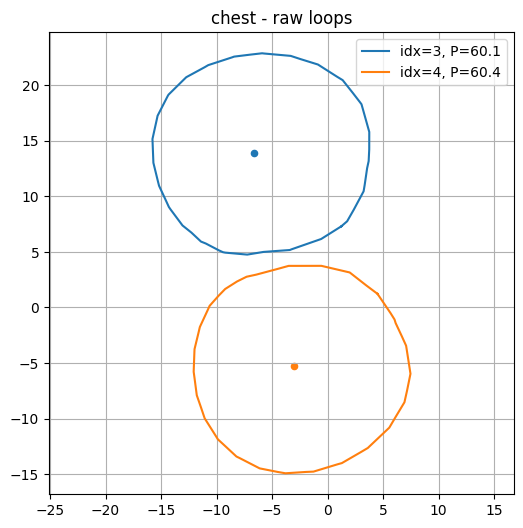

Selected loop index: 4
Selected loop raw perimeter: 60.44257187586839
Selected loop raw area: 287.8059321695639


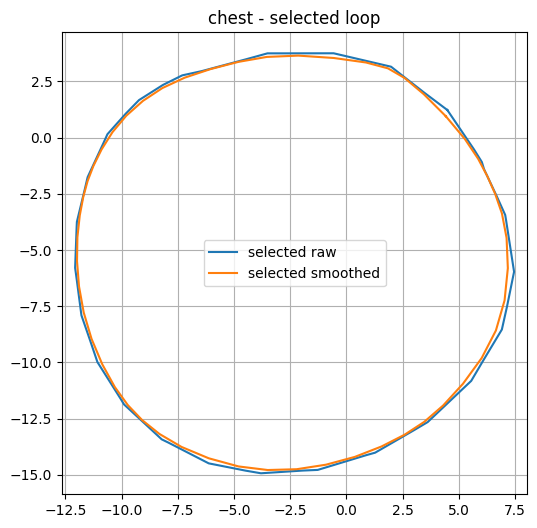

Smoothed perimeter: 59.60487855681571
Convex-hull perimeter: 59.60487855681571

--- Measuring waist at height 77.00 cm ---
Valid loops found: 3
Loop idx=0 | P=19.74 | A=29.61 | C=[ 0.40503135 37.45026322]
Loop idx=1 | P=96.39 | A=706.44 | C=[-2.42282874  1.62770567]
Loop idx=2 | P=19.61 | A=29.47 | C=[  4.47541574 -41.37943263]


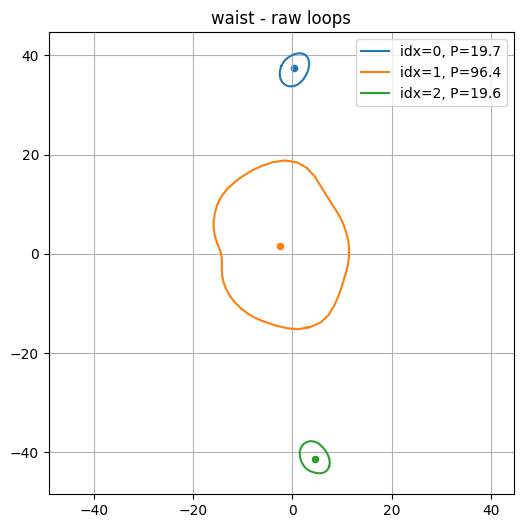

Selected loop index: 1
Selected loop raw perimeter: 96.38650326957419
Selected loop raw area: 706.4425855900366


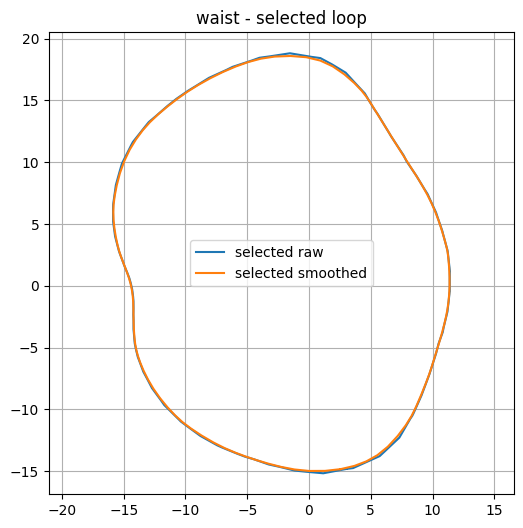

Smoothed perimeter: 95.82842452841892
Convex-hull perimeter: 95.75530724358192

--- Measuring hip at height 90.12 cm ---
Valid loops found: 3
Loop idx=0 | P=104.15 | A=665.05 | C=[-5.1669734   2.88696732]
Loop idx=1 | P=21.28 | A=25.84 | C=[-1.58239142 46.14699466]
Loop idx=2 | P=19.71 | A=20.57 | C=[  2.94157119 -48.33455562]


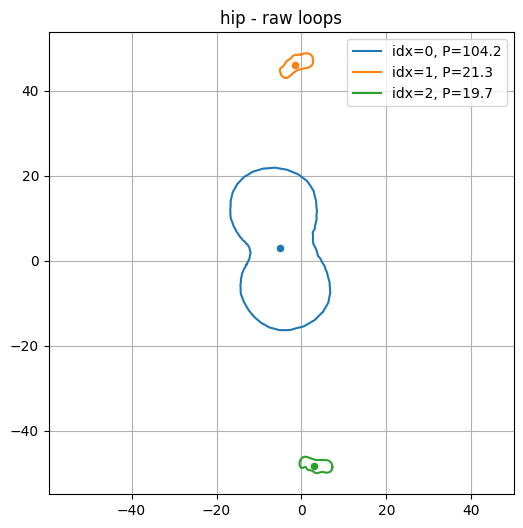

Selected loop index: 0
Selected loop raw perimeter: 104.15107880203713
Selected loop raw area: 665.0510704382225


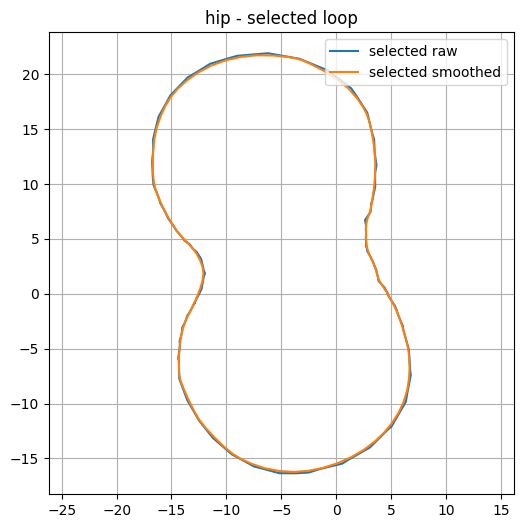

Smoothed perimeter: 102.88001176237722
Convex-hull perimeter: 100.70466664961953

--- Measuring thigh at height 48.13 cm ---
Valid loops found: 3
Loop idx=0 | P=88.87 | A=572.62 | C=[1.79128365 0.47534737]
Loop idx=1 | P=31.18 | A=76.31 | C=[-3.381036   22.67947715]
Loop idx=2 | P=31.25 | A=76.60 | C=[ -0.08117894 -22.61587218]


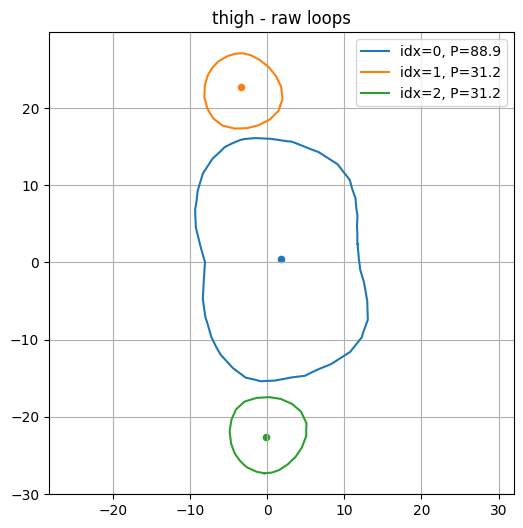

Selected loop index: 1
Selected loop raw perimeter: 31.18052101843324
Selected loop raw area: 76.3145575725141


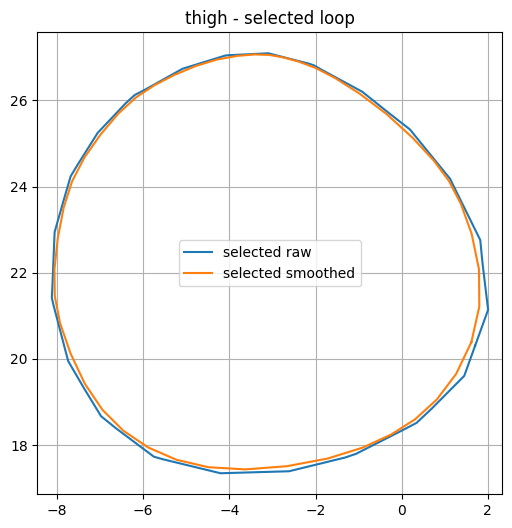

Smoothed perimeter: 30.619922544872505
Convex-hull perimeter: 30.619922544872505

Measurement results:
chest = 59.60487855681571
waist = 95.75530724358192
hip = 100.70466664961953
thigh = 30.619922544872505


In [15]:
# Cell 15 — Measure all slices
# Safety check
if "mesh" not in globals():
    raise RuntimeError("Mesh not loaded. Please run Cell 3 first.")

# Print status
print("Measuring all body slices...")

# Create dictionary for measurements
measurements = {}

# Measure chest
measurements["chest"] = measure_slice(
    mesh=mesh,
    h=slice_heights["chest"],
    label="chest",
    axis=vertical_axis,
    smooth_iterations=smooth_iterations,
    use_convex_hull=use_convex_hull_for_body
)

# Measure waist
measurements["waist"] = measure_slice(
    mesh=mesh,
    h=slice_heights["waist"],
    label="waist",
    axis=vertical_axis,
    smooth_iterations=smooth_iterations,
    use_convex_hull=use_convex_hull_for_body
)

# Measure hip
measurements["hip"] = measure_slice(
    mesh=mesh,
    h=slice_heights["hip"],
    label="hip",
    axis=vertical_axis,
    smooth_iterations=smooth_iterations,
    use_convex_hull=use_convex_hull_for_body
)

# Measure thigh
measurements["thigh"] = measure_slice(
    mesh=mesh,
    h=slice_heights["thigh"],
    label="thigh",
    axis=vertical_axis,
    smooth_iterations=smooth_iterations,
    use_convex_hull=False
)

# Print results
print("\nMeasurement results:")
for name, value in measurements.items():
    print(name, "=", value)

In [16]:
# Cell 16 — Final measurements
# Print status
print("Preparing final measurements...")

# Extract values
chest_cm = measurements["chest"]
waist_cm = measurements["waist"]
hip_cm = measurements["hip"]
thigh_cm = measurements["thigh"]
height_cm = scaled_height

# Print values
print(f"Chest circumference (cm): {chest_cm:.2f}" if chest_cm is not None else "Chest circumference: not found")
print(f"Waist circumference (cm): {waist_cm:.2f}" if waist_cm is not None else "Waist circumference: not found")
print(f"Hip circumference (cm): {hip_cm:.2f}" if hip_cm is not None else "Hip circumference: not found")
print(f"Thigh circumference (cm): {thigh_cm:.2f}" if thigh_cm is not None else "Thigh circumference: not found")
print(f"Height (cm): {height_cm:.2f}")

Preparing final measurements...
Chest circumference (cm): 59.60
Waist circumference (cm): 95.76
Hip circumference (cm): 100.70
Thigh circumference (cm): 30.62
Height (cm): 175.00


In [17]:
#Cell 17 — Compute estimated weight
# Print status
print("Computing estimated weight...")

# Check required values
required_values = [waist_cm, hip_cm, chest_cm, thigh_cm, height_cm]

# Stop if anything is missing
if any(v is None for v in required_values):
    print("Weight could not be computed because one or more measurements are missing.")
else:
    # Apply the formula
    weight = (
        -96.2
        + 0.45 * waist_cm
        + 0.26 * hip_cm
        + 0.20 * chest_cm
        + 0.15 * thigh_cm
        + 0.70 * height_cm
    )

    # Print the estimated weight
    print(f"Estimated weight: {weight:.2f} kg")

Computing estimated weight...
Estimated weight: 112.09 kg


In [18]:
# Cell 18 — Sanity check extents
# Print status
print("Sanity-checking scaled mesh extents...")

# Print full extents
print("Scaled extents:", mesh.extents)

# Build list of axes
axes = [0, 1, 2]

# Remove vertical axis
axes.remove(vertical_axis)

# Print horizontal extents
print("Horizontal extent 1:", mesh.extents[axes[0]])
print("Horizontal extent 2:", mesh.extents[axes[1]])

# Print vertical extent
print("Vertical extent:", mesh.extents[vertical_axis])

Sanity-checking scaled mesh extents...
Scaled extents: [104.05194353 175.          54.94841133]
Horizontal extent 1: 104.05194353276676
Horizontal extent 2: 54.94841132896327
Vertical extent: 175.0


In [19]:
# Cell 19 — Final summary
# Print summary
print("\n========== FINAL SUMMARY ==========")

# Print height
print(f"Height (cm): {height_cm:.2f}")

# Print chest
print(f"Chest circumference (cm): {chest_cm:.2f}" if chest_cm is not None else "Chest circumference: not found")

# Print waist
print(f"Waist circumference (cm): {waist_cm:.2f}" if waist_cm is not None else "Waist circumference: not found")

# Print hip
print(f"Hip circumference (cm): {hip_cm:.2f}" if hip_cm is not None else "Hip circumference: not found")

# Print thigh
print(f"Thigh circumference (cm): {thigh_cm:.2f}" if thigh_cm is not None else "Thigh circumference: not found")

# Print weight if available
if all(v is not None for v in [waist_cm, hip_cm, chest_cm, thigh_cm]):
    print(f"Estimated weight (kg): {weight:.2f}")
else:
    print("Estimated weight (kg): could not compute")


========== FINAL SUMMARY ==========
Height (cm): 175.00
Chest circumference (cm): 59.60
Waist circumference (cm): 95.76
Hip circumference (cm): 100.70
Thigh circumference (cm): 30.62
Estimated weight (kg): 112.09
